<a href="https://colab.research.google.com/github/dee1empire/-ITAI-1371-ML-Labs-/blob/main/Another_copy_of_L08_DeloresBledsoe_ITAI1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve

# Generate some synthetic data
np.random.seed(0)
X = np.linspace(-5, 5, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.5, 100)

# Continuous points to plot smooth model prediction curves
X_plot = np.linspace(-5, 5, 500).reshape(-1, 1)




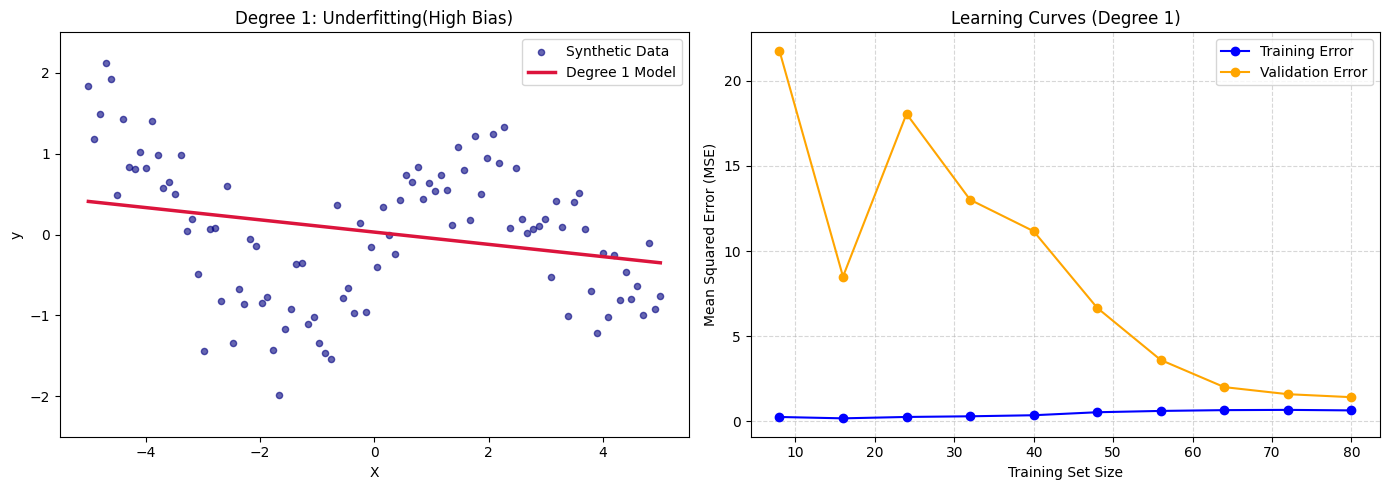

In [ ]:
# Force correct
X = np.asarray(X).reshape(-1, 1)
y = np.asarray(y).ravel()
X_plot = np.asarray(X_plot).reshape(-1, 1)

# Create a 1-row, 2-column layout for a clean sis-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
degree = 1

# Train the model
model_deg1 = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model_deg1.fit(X, y)

# Left Panel: Visualizing the Fit
axes[0].scatter(X, y, color='navy', s=20, alpha=0.6, label='Synthetic Data')
axes[0].plot(X_plot, model_deg1.predict(X_plot), color='crimson', lw=2.5, label='Degree 1 Model')
axes[0].set_ylim(-2.5, 2.5)
axes[0].set_title("Degree 1: Underfitting(High Bias)")
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].legend()

# Right Panel: Learning Curve Computation & Visualization
train_sizes, train_scores, test_scores = learning_curve(
    model_deg1, X, y, cv=5, scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=0)

train_errors = -np.mean(train_scores, axis=1)
test_errors = -np.mean(test_scores, axis=1)

axes[1].plot(train_sizes, train_errors, 'o-', color='blue', label='Training Error')
axes[1].plot(train_sizes, test_errors, 'o-', color='orange', label='Validation Error')
axes[1].set_title('Learning Curves (Degree 1)')
axes[1].set_xlabel('Training Set Size')
axes[1].set_ylabel('Mean Squared Error (MSE)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

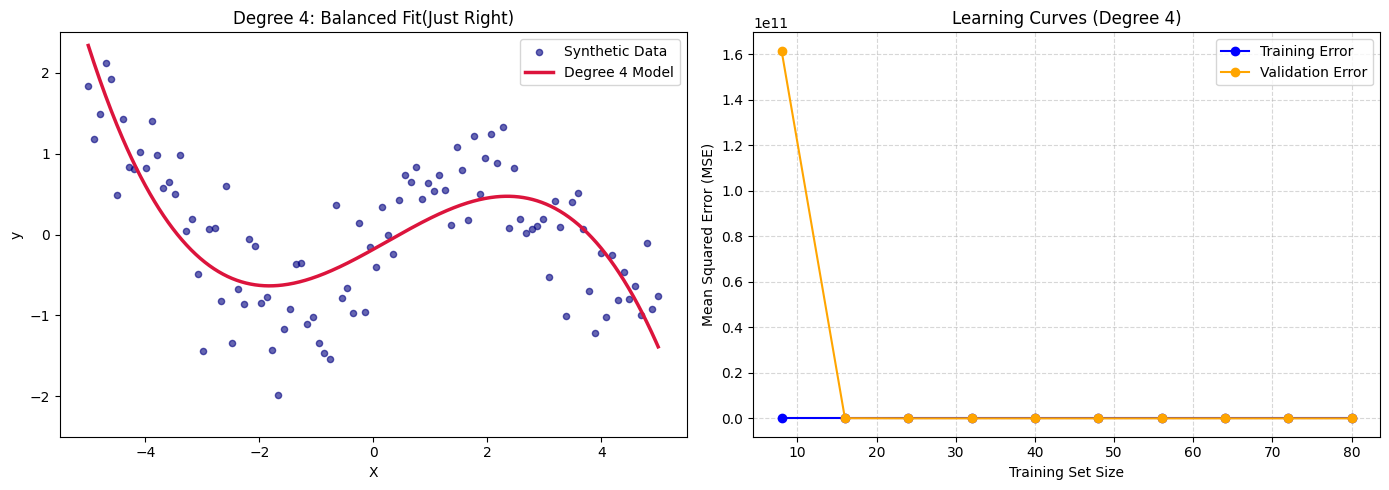

In [ ]:
X = np.asarray(X).reshape(-1, 1)
y = np.asarray(y).ravel()
X_plot = np.asarray(X_plot).reshape(-1, 1)

# Create a 1-row, 2-column layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
degree = 4

# Train the model
model_deg4 = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model_deg4.fit(X, y)

# Left Panel: Visualizing the Fit
axes[0].scatter(X, y, color='navy', s=20, alpha=0.6, label='Synthetic Data')
axes[0].plot(X_plot, model_deg4.predict(X_plot), color='crimson', lw=2.5, label='Degree 4 Model')
axes[0].set_ylim(-2.5, 2.5)
axes[0].set_title("Degree 4: Balanced Fit(Just Right)")
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].legend()

# Right Panel: Learning Curve Computation & Visualization
train_sizes, train_scores, test_scores = learning_curve(
    model_deg4, X, y, cv=5, scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=0)

train_errors = -np.mean(train_scores, axis=1)
test_errors = -np.mean(test_scores, axis=1)

axes[1].plot(train_sizes, train_errors, 'o-', color='blue', label='Training Error')
axes[1].plot(train_sizes, test_errors, 'o-', color='orange', label='Validation Error')
axes[1].set_title('Learning Curves (Degree 4)')
axes[1].set_xlabel('Training Set Size')
axes[1].set_ylabel('Mean Squared Error (MSE)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

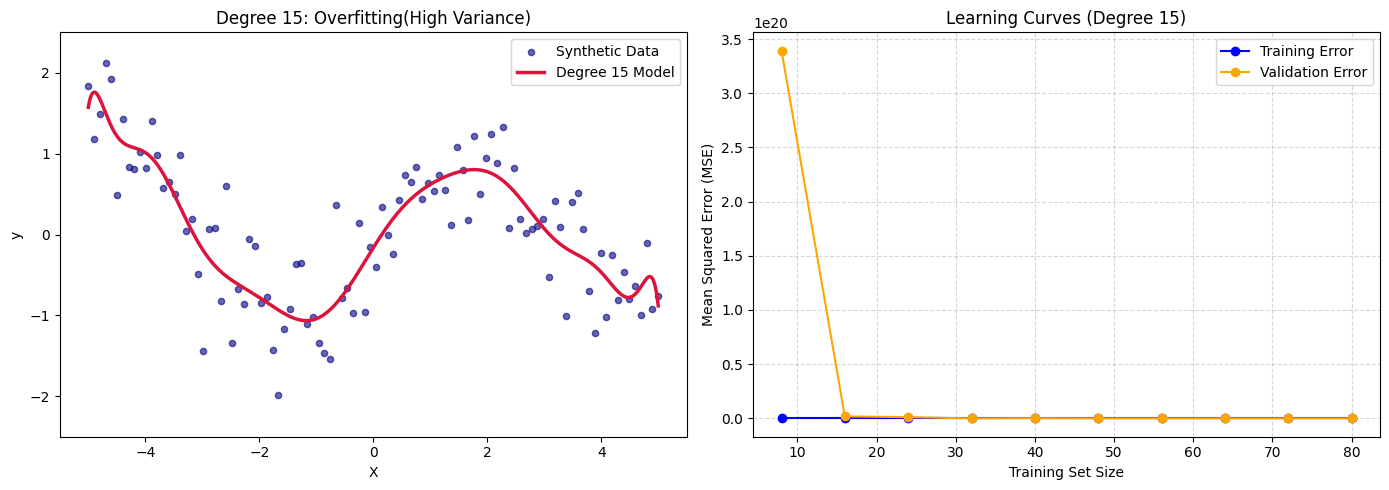

In [ ]:
X = np.asarray(X).reshape(-1, 1)
y = np.asarray(y).ravel()
X_plot = np.asarray(X_plot).reshape(-1, 1)

# Create a 1-row, 2-column layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
degree = 15

# Train the model
model_deg15 = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model_deg15.fit(X, y)

# Left Panel: Visualizing the Fit
axes[0].scatter(X, y, color='navy', s=20, alpha=0.6, label='Synthetic Data')
axes[0].plot(X_plot, model_deg15.predict(X_plot), color='crimson', lw=2.5, label='Degree 15 Model')
axes[0].set_ylim(-2.5, 2.5)
axes[0].set_title("Degree 15: Overfitting(High Variance)")
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].legend()

# Right Panel: Learning Curve Computation & Visualization
train_sizes, train_scores, test_scores = learning_curve(
    model_deg15, X, y, cv=5, scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=0)

train_errors = -np.mean(train_scores, axis=1)
test_errors = -np.mean(test_scores, axis=1)

axes[1].plot(train_sizes, train_errors, 'o-', color='blue', label='Training Error')
axes[1].plot(train_sizes, test_errors, 'o-', color='orange', label='Validation Error')
axes[1].set_title('Learning Curves (Degree 15)')
axes[1].set_xlabel('Training Set Size')
axes[1].set_ylabel('Mean Squared Error (MSE)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# Defining the module's exact standard helper function for R2 score learning curves
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
                        plt.figure(figsize=(10, 6))
                        plt.title(title)
                        if ylim is not None:
                            plt.ylim(*ylim)
                        plt.xlabel("Training examples")
                        plt.ylabel("Score")

                        train_sizes, train_scores, test_scores = learning_curve(
                            estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='r2')

                        train_scores_mean = np.mean(train_scores, axis=1)
                        train_scores_std = np.std(train_scores, axis=1)
                        test_scores_mean = np.mean(test_scores, axis=1)
                        test_scores_std = np.std(test_scores, axis=1)

                        plt.grid(True)

                        # Fill variance regions
                        plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                                        train_scores_mean + train_scores_std, alpha=0.1,
                                        color="r")
                        plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                                        test_scores_mean + test_scores_std, alpha=0.1, color="g")

                        # Plot line curves
                        plt.plot(train_sizes, train_scores_mean, color="r", label="Training score")
                        plt.plot(train_sizes, test_scores_mean, color="g", label="Cross-validation score")

                        plt.legend(loc="best")
                        return plt

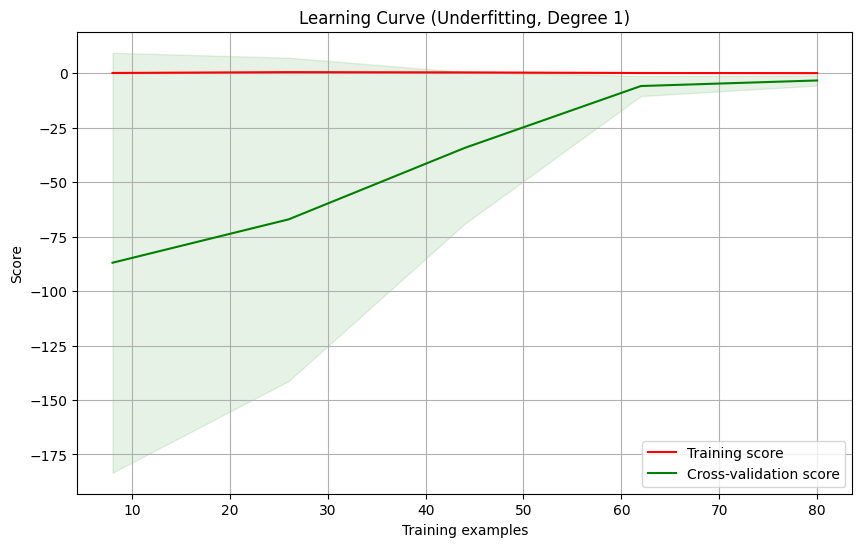

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

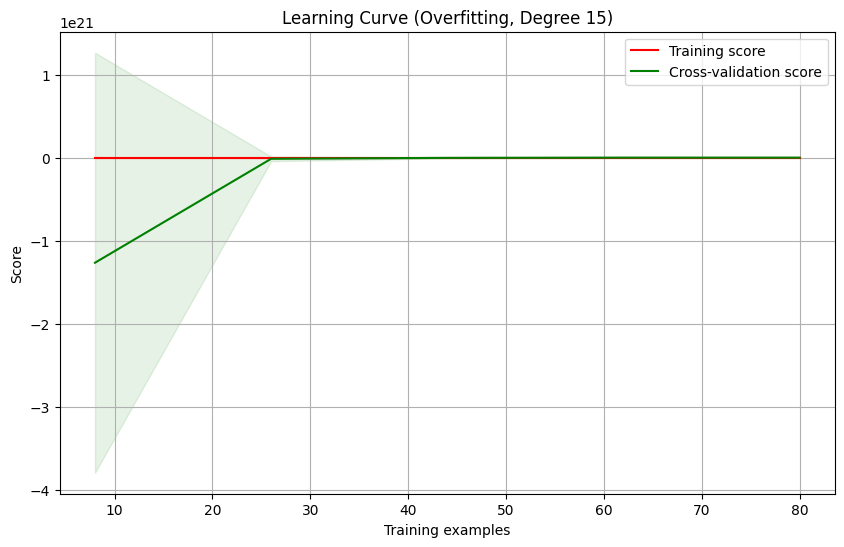

In [ ]:
# Create the underfit and overfit models exactly variable names
underfit_model = make_pipeline(PolynomialFeatures(1), LinearRegression())
overfit_model = make_pipeline(PolynomialFeatures(15), LinearRegression())

# Plot the learning curve for the underfit model
plot_learning_curve(underfit_model, "Learning Curve (Underfitting, Degree 1)", X, y, cv=5)
plt.show()

# Plot the learning curve for the overfit model
plot_learning_curve(overfit_model, "Learning Curve (Overfitting, Degree 15)", X, y, cv=5)

                                    **KNOWLEDGE CHECK**


1. In the first plot of the three models, which model (degree 1, 4, or 15) is underfitting, which is overfitting, and which is a good fit? Explain your reasoning.

   *** Degree 1 (Underfitting): applies a straight line that cannot capture the curved wave structure, introducing high systematic error (high bias).
   *** Degree 4 (Good Fit): smoothly follows the true mathematical pattern without reacting to the scatteredrandom errorsin individual points.
   *** Degree 15 (Overfitting): It wiggles aggressively to touch all data points, meaning it has memorized the random sample noise instead of learning the true curve pattern (high variance).



2. Looking at the learning curve for the underfitting model, what do you observe about the training and cross-validation scores? What does this tell you?

***From observation: Both errors quickly flatten and settle at a permanently high value.
For the meaning: This tells us that increasing the size of our dataset will not improve the results. The model structure lacks the architectural capacity to map the pattern.


3. Looking at the learning curve for the overfitting model, what do you observe about the gap between the training and cross-validation scores? What does this tell you?

*** For observation: There is a distinct, wide gap between the perfect performance on the training data and the poor score on validation data.
And for the meaning: This indicates high variance. The model is overly receptive to its specific training data subset and cannot generalize effectively to new observations.